<a href="https://colab.research.google.com/github/shavel28/StockSight-AI-PJK-GM073/blob/main/Notebooks/Data_Engineering_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PROJECT: STOCKSIGHT AI (PJK-GM073)

ROLE: DATA ENGINEER
Shava Selvia Ramadhani Subekti

TASK:
Data Ingestion, Data Cleaning & Validation,
Holiday Integration, Time Series Transformation,
Feature Engineering (Calendar, Lag, Rolling Mean),
Outlier Analysis, Safety Stock & Reorder Point Calculation,
Forecasting Dataset Preparation and Export

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

1. INSTALL & IMPORT LIBRARIES

In [1]:
!pip install kagglehub holidays -q
import pandas as pd
import numpy as np
import holidays
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns

 2. DATA INGESTION (Ambil Data dari Kaggle)

In [2]:
print("--- Mengunduh Dataset ---")

path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")
file_path = os.path.join(path, "train.csv")

df_raw = pd.read_csv(file_path)

print(f"Dataset berhasil dimuat. Ukuran: {df_raw.shape}")
df_raw.head()

--- Mengunduh Dataset ---


100%|██████████| 480k/480k [00:00<00:00, 57.4MB/s]

Extracting files...
Dataset berhasil dimuat. Ukuran: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


 3. EXPLORATORY DATA ANALYSIS (EDA) AWAL

In [3]:
print("--- Informasi Dataset ---")
print(df_raw.info())

print("\n--- Statistik Sales ---")
print(df_raw['Sales'].describe())

print("\n--- Cek Missing Value ---")
print(df_raw.isnull().sum())

print("\n--- Cek Duplikasi ---")
print(df_raw.duplicated().sum())

print("\n--- Cek Kolom Kategori ---")
print(df_raw[['Category', 'Sub-Category']].nunique())
print(df_raw['Category'].value_counts())

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-nu

 4. DATA CLEANING & VALIDASI INPUT

In [4]:
print("--- Memulai Proses Cleaning ---")

df_cleaned = df_raw.copy()

# Hapus duplikasi
before_dup = len(df_cleaned)
df_cleaned = df_cleaned.drop_duplicates()
print(f"Duplikasi dihapus: {before_dup - len(df_cleaned)}")

# Hapus baris kosong pada kolom penting
before_null = len(df_cleaned)
df_cleaned = df_cleaned.dropna(subset=['Order Date', 'Sales', 'Category'])
print(f"Baris kosong dihapus: {before_null - len(df_cleaned)}")

# Validasi format tanggal
df_cleaned['Order Date'] = pd.to_datetime(
    df_cleaned['Order Date'],
    dayfirst=True,
    errors='coerce'
)

# Hapus tanggal yang gagal dikonversi
before_invalid_date = len(df_cleaned)
df_cleaned = df_cleaned.dropna(subset=['Order Date'])
print(f"Tanggal invalid dihapus: {before_invalid_date - len(df_cleaned)}")

# Pastikan Sales numerik
df_cleaned['Sales'] = pd.to_numeric(df_cleaned['Sales'], errors='coerce')
df_cleaned = df_cleaned.dropna(subset=['Sales'])

# Hapus sales negatif jika ada
df_cleaned = df_cleaned[df_cleaned['Sales'] >= 0]

print("Cleaning selesai.")
print(df_cleaned.shape)

--- Memulai Proses Cleaning ---
Duplikasi dihapus: 0
Baris kosong dihapus: 0
Tanggal invalid dihapus: 0
Cleaning selesai.
(9800, 18)


5. INTEGRASI DATASET EKSTERNAL (Holiday Indonesia)

In [5]:
print("--- Integrasi Data Libur Indonesia ---")

min_year = df_cleaned['Order Date'].dt.year.min()
max_year = df_cleaned['Order Date'].dt.year.max()

id_holidays = holidays.Indonesia(years=range(min_year, max_year + 1))

df_cleaned['is_holiday'] = df_cleaned['Order Date'].apply(
    lambda x: 1 if x in id_holidays else 0
)

print(df_cleaned[['Order Date', 'is_holiday']].head())
print("Jumlah transaksi pada hari libur:", df_cleaned['is_holiday'].sum())

--- Integrasi Data Libur Indonesia ---
  Order Date  is_holiday
0 2017-11-08           0
1 2017-11-08           0
2 2017-06-12           0
3 2016-10-11           0
4 2016-10-11           0
Jumlah transaksi pada hari libur: 439


### Note

Dataset utama berasal dari Kaggle (Sales Forecasting Dataset), sedangkan fitur hari libur diperoleh dari library `holidays` dengan kalender Hari Libur Nasional Indonesia sebagai variabel eksternal untuk mendukung forecasting.

Fitur `is_holiday` digunakan untuk membantu model mengenali pola perubahan permintaan yang dipengaruhi oleh hari libur nasional.

6. Time Series Global untuk Baseline

In [6]:
print("--- Membuat Time Series Global ---")

df_ts_global = df_cleaned.groupby('Order Date').agg({
    'Sales': 'sum',
    'is_holiday': 'max'
}).reset_index()

df_ts_global.columns = ['ds', 'y', 'is_holiday']
df_ts_global = df_ts_global.sort_values('ds').reset_index(drop=True)

df_ts_global.head()

--- Membuat Time Series Global ---


,ds,y,is_holiday
0,2015-01-03,16.448,1
1,2015-01-04,288.060,0
2,2015-01-05,19.536,0
3,2015-01-06,4407.100,0
4,2015-01-07,87.158,0


7. Time Series Per Kategori Produk

In [7]:
print("--- Membuat Time Series Per Kategori Produk ---")

df_ts_category = df_cleaned.groupby(['Order Date', 'Category']).agg({
    'Sales': 'sum',
    'is_holiday': 'max'
}).reset_index()

df_ts_category = df_ts_category.rename(columns={
    'Order Date': 'ds',
    'Sales': 'y'
})

df_ts_category = df_ts_category.sort_values(['Category', 'ds']).reset_index(drop=True)

df_ts_category.head()

--- Membuat Time Series Per Kategori Produk ---


,ds,Category,y,is_holiday
0,2015-01-06,Furniture,2573.820,0
1,2015-01-07,Furniture,76.728,0
2,2015-01-10,Furniture,51.940,0
3,2015-01-11,Furniture,9.940,0
4,2015-01-13,Furniture,879.939,0


8. Cek dan Lengkapi Missing Date Per Kategori




In [8]:
print("--- Cek Missing Date Per Kategori ---")

all_categories = df_ts_category['Category'].unique()
date_range = pd.date_range(
    start=df_ts_category['ds'].min(),
    end=df_ts_category['ds'].max(),
    freq='D'
)

full_index = pd.MultiIndex.from_product(
    [date_range, all_categories],
    names=['ds', 'Category']
)

df_ts_category_full = (
    df_ts_category
    .set_index(['ds', 'Category'])
    .reindex(full_index)
    .reset_index()
)

df_ts_category_full['y'] = df_ts_category_full['y'].fillna(0)
df_ts_category_full['is_holiday'] = df_ts_category_full['is_holiday'].fillna(0).astype(int)

df_ts_category_full = df_ts_category_full.sort_values(['Category', 'ds']).reset_index(drop=True)

df_ts_category_full.head()

--- Cek Missing Date Per Kategori ---


,ds,Category,y,is_holiday
0,2015-01-03,Furniture,0.000,0
1,2015-01-04,Furniture,0.000,0
2,2015-01-05,Furniture,0.000,0
3,2015-01-06,Furniture,2573.820,0
4,2015-01-07,Furniture,76.728,0


9. Calendar Feature

In [9]:
print("--- Menambahkan Calendar Feature ---")

df_ts_category_full['day_of_week'] = df_ts_category_full['ds'].dt.dayofweek
df_ts_category_full['day_name'] = df_ts_category_full['ds'].dt.day_name()
df_ts_category_full['month'] = df_ts_category_full['ds'].dt.month
df_ts_category_full['quarter'] = df_ts_category_full['ds'].dt.quarter
df_ts_category_full['year'] = df_ts_category_full['ds'].dt.year
df_ts_category_full['is_weekend'] = df_ts_category_full['day_of_week'].isin([5, 6]).astype(int)

df_ts_category_full.head()

--- Menambahkan Calendar Feature ---


,ds,Category,y,is_holiday,day_of_week,day_name,month,quarter,year,is_weekend
0,2015-01-03,Furniture,0.000,0,5,Saturday,1,1,2015,1
1,2015-01-04,Furniture,0.000,0,6,Sunday,1,1,2015,1
2,2015-01-05,Furniture,0.000,0,0,Monday,1,1,2015,0
3,2015-01-06,Furniture,2573.820,0,1,Tuesday,1,1,2015,0
4,2015-01-07,Furniture,76.728,0,2,Wednesday,1,1,2015,0


10. Lag Feature

In [10]:
print("--- Menambahkan Lag Feature ---")

df_ts_category_full['lag_1'] = df_ts_category_full.groupby('Category')['y'].shift(1)
df_ts_category_full['lag_7'] = df_ts_category_full.groupby('Category')['y'].shift(7)
df_ts_category_full['lag_14'] = df_ts_category_full.groupby('Category')['y'].shift(14)

df_ts_category_full.head(20)

--- Menambahkan Lag Feature ---


,ds,Category,y,is_holiday,day_of_week,day_name,month,quarter,year,is_weekend,lag_1,lag_7,lag_14
0,2015-01-03,Furniture,0.000,0,5,Saturday,1,1,2015,1,NaN,NaN,NaN
1,2015-01-04,Furniture,0.000,0,6,Sunday,1,1,2015,1,0.000,NaN,NaN
2,2015-01-05,Furniture,0.000,0,0,Monday,1,1,2015,0,0.000,NaN,NaN
3,2015-01-06,Furniture,2573.820,0,1,Tuesday,1,1,2015,0,0.000,NaN,NaN
4,2015-01-07,Furniture,76.728,0,2,Wednesday,1,1,2015,0,2573.820,NaN,NaN
5,2015-01-08,Furniture,0.000,0,3,Thursday,1,1,2015,0,76.728,NaN,NaN
6,2015-01-09,Furniture,0.000,0,4,Friday,1,1,2015,0,0.000,NaN,NaN
7,2015-01-10,Furniture,51.940,0,5,Saturday,1,1,2015,1,0.000,0.000,NaN
8,2015-01-11,Furniture,9.940,0,6,Sunday,1,1,2015,1,51.940,0.000,NaN
9,2015-01-12,Furniture,0.000,0,0,Monday,1,1,2015,0,9.940,0.000,NaN


11. Rolling Mean / Rolling Statistics

In [11]:
print("--- Menambahkan Rolling Mean ---")

df_ts_category_full['rolling_mean_7'] = (
    df_ts_category_full
    .groupby('Category')['y']
    .shift(1)
    .rolling(window=7)
    .mean()
)

df_ts_category_full['rolling_mean_30'] = (
    df_ts_category_full
    .groupby('Category')['y']
    .shift(1)
    .rolling(window=30)
    .mean()
)

df_ts_category_full.head(35)

--- Menambahkan Rolling Mean ---


,ds,Category,y,is_holiday,day_of_week,day_name,month,quarter,year,is_weekend,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_30
0,2015-01-03,Furniture,0.000,0,5,Saturday,1,1,2015,1,NaN,NaN,NaN,NaN,NaN
1,2015-01-04,Furniture,0.000,0,6,Sunday,1,1,2015,1,0.000,NaN,NaN,NaN,NaN
2,2015-01-05,Furniture,0.000,0,0,Monday,1,1,2015,0,0.000,NaN,NaN,NaN,NaN
3,2015-01-06,Furniture,2573.820,0,1,Tuesday,1,1,2015,0,0.000,NaN,NaN,NaN,NaN
4,2015-01-07,Furniture,76.728,0,2,Wednesday,1,1,2015,0,2573.820,NaN,NaN,NaN,NaN
5,2015-01-08,Furniture,0.000,0,3,Thursday,1,1,2015,0,76.728,NaN,NaN,NaN,NaN
6,2015-01-09,Furniture,0.000,0,4,Friday,1,1,2015,0,0.000,NaN,NaN,NaN,NaN
7,2015-01-10,Furniture,51.940,0,5,Saturday,1,1,2015,1,0.000,0.000,NaN,378.649714,NaN
8,2015-01-11,Furniture,9.940,0,6,Sunday,1,1,2015,1,51.940,0.000,NaN,386.069714,NaN
9,2015-01-12,Furniture,0.000,0,0,Monday,1,1,2015,0,9.940,0.000,NaN,387.489714,NaN


12. Handling Missing Value dari Feature Engineering

In [12]:
print("--- Handling Missing Value Feature Engineering ---")

df_ts_category_full[['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_30']] = (
    df_ts_category_full[['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_30']]
    .fillna(0)
)

print(df_ts_category_full.isnull().sum())

--- Handling Missing Value Feature Engineering ---
ds                 0
Category           0
y                  0
is_holiday         0
day_of_week        0
day_name           0
month              0
quarter            0
year               0
is_weekend         0
lag_1              0
lag_7              0
lag_14             0
rolling_mean_7     0
rolling_mean_30    0
dtype: int64


13. Outlier Analysis Per Kategori

In [13]:
print("--- Cek Outlier Per Kategori ---")

outlier_summary = []

for category in df_ts_category_full['Category'].unique():
    temp = df_ts_category_full[df_ts_category_full['Category'] == category]

    Q1 = temp['y'].quantile(0.25)
    Q3 = temp['y'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = temp[(temp['y'] < lower_bound) | (temp['y'] > upper_bound)].shape[0]

    outlier_summary.append({
        'Category': category,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outlier_count
    })

df_outlier_summary = pd.DataFrame(outlier_summary)
df_outlier_summary

--- Cek Outlier Per Kategori ---


,Category,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Furniture,0.000,630.7590,630.7590,-946.13850,1576.89750,130
1,Office Supplies,12.564,563.0410,550.4770,-813.15150,1388.75650,140
2,Technology,0.000,579.4865,579.4865,-869.22975,1448.71625,153


14. Visualisasi Tren Penjualan Per Kategori

--- Visualisasi Tren Penjualan Per Kategori ---


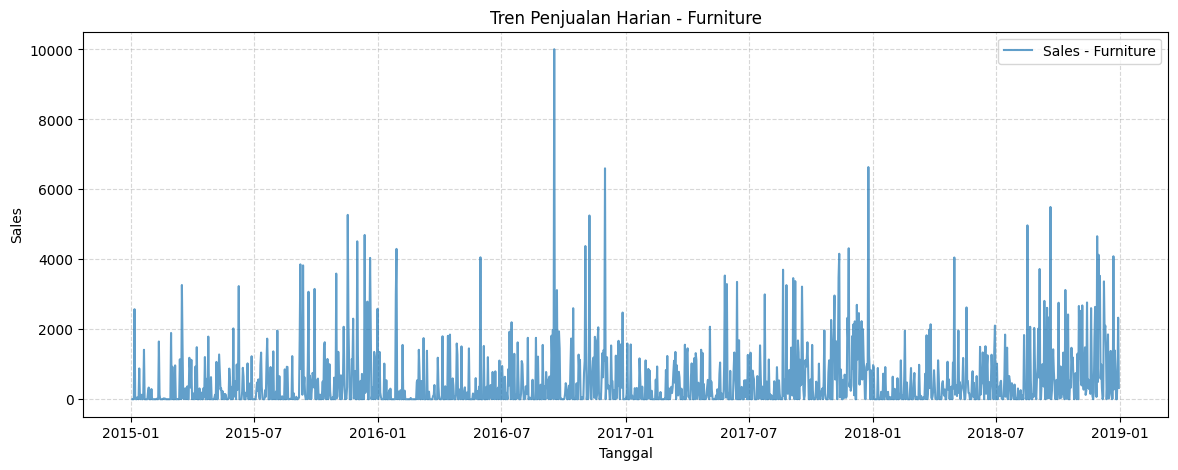

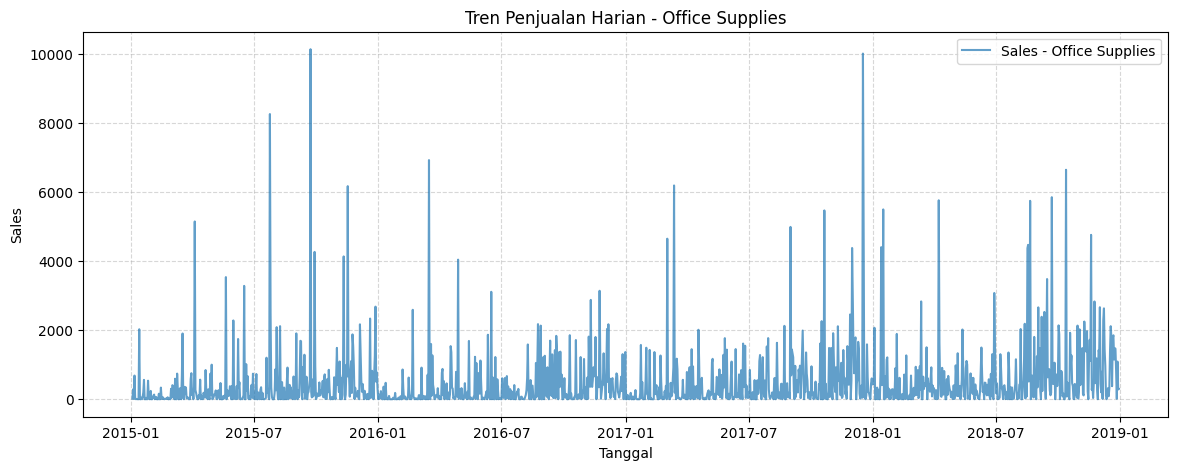

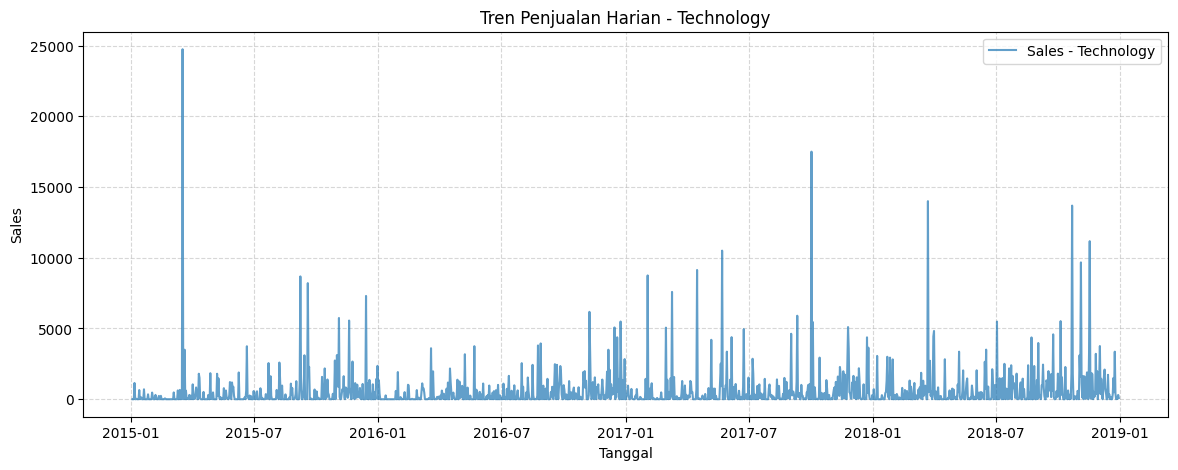

In [14]:
print("--- Visualisasi Tren Penjualan Per Kategori ---")

for category in df_ts_category_full['Category'].unique():
    temp = df_ts_category_full[df_ts_category_full['Category'] == category]

    plt.figure(figsize=(14, 5))
    plt.plot(temp['ds'], temp['y'], label=f'Sales - {category}', alpha=0.7)
    plt.title(f'Tren Penjualan Harian - {category}')
    plt.xlabel('Tanggal')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

15. Safety Stock & Reorder Point Per Kategori

In [15]:
print("--- Perhitungan Safety Stock & Reorder Point ---")

lead_time_days = 7
service_level_z = 1.65  # Service level 95%

inventory_summary = []

for category in df_ts_category_full['Category'].unique():

    temp = df_ts_category_full[
        df_ts_category_full['Category'] == category
    ]

    avg_daily_demand = temp['y'].mean()
    std_daily_demand = temp['y'].std()

    safety_stock = (
        service_level_z
        * std_daily_demand
        * np.sqrt(lead_time_days)
    )

    reorder_point = (
        avg_daily_demand * lead_time_days
        + safety_stock
    )

    inventory_summary.append({
        'Category': category,
        'Average_Daily_Demand': round(avg_daily_demand, 2),
        'Std_Daily_Demand': round(std_daily_demand, 2),
        'Safety_Stock': round(safety_stock, 2),
        'Reorder_Point': round(reorder_point, 2)
    })

inventory_df = pd.DataFrame(inventory_summary)

print(inventory_df)

inventory_df.head()

--- Perhitungan Safety Stock & Reorder Point ---
          Category  Average_Daily_Demand  Std_Daily_Demand  Safety_Stock  \
0        Furniture                499.77            881.40       3847.73   
1  Office Supplies                483.83            911.30       3978.26   
2       Technology                567.53           1442.24       6296.08   

   Reorder_Point  
0        7346.09  
1        7365.06  
2       10268.78  


,Category,Average_Daily_Demand,Std_Daily_Demand,Safety_Stock,Reorder_Point
0,Furniture,499.77,881.40,3847.73,7346.09
1,Office Supplies,483.83,911.30,3978.26,7365.06
2,Technology,567.53,1442.24,6296.08,10268.78


16. Export Dataset untuk ML Engineer

In [16]:
print("--- Export Dataset untuk ML Engineer ---")

output_dir = "processed_data"
os.makedirs(output_dir, exist_ok=True)

# Dataset Forecasting Global
df_ts_global.to_csv(
    f"{output_dir}/time_series_global.csv",
    index=False
)

# Dataset Forecasting Per Kategori + Feature Engineering
df_ts_category_full.to_csv(
    f"{output_dir}/time_series_category_feature_engineered.csv",
    index=False
)

# Ringkasan Outlier
df_outlier_summary.to_csv(
    f"{output_dir}/outlier_summary.csv",
    index=False
)

# Safety Stock & Reorder Point
inventory_df.to_csv(
    f"{output_dir}/inventory_summary.csv",
    index=False
)

print("\nDataset berhasil diexport:")
print("- time_series_global.csv")
print("- time_series_category_feature_engineered.csv")
print("- outlier_summary.csv")
print("- inventory_summary.csv")

--- Export Dataset untuk ML Engineer ---

Dataset berhasil diexport:
- time_series_global.csv
- time_series_category_feature_engineered.csv
- outlier_summary.csv
- inventory_summary.csv
